<a href="https://colab.research.google.com/github/Taqi05/ChurnPrediction3/blob/main/%5B4%5D_UAS_BengkelKoding_ChurnPrediction_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science
## Customer Churn Prediction - Sales & Marketing Dataset
---
**Dataset:** Sales and Marketing Customer Dataset (15.000 records, 30 kolom)  
**Target:** `churn` (0 = tidak churn, 1 = churn)  
**Tujuan:** Membangun 9 model dari 3 kategori x 3 skenario eksperimen

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import joblib
from imblearn.over_sampling import SMOTE

print('Semua library berhasil diimport')

Semua library berhasil diimport


---
# BAGIAN 1: EXPLORATORY DATA ANALYSIS (EDA)

### 1.1 Load Dataset & Tampilkan 5 Baris Pertama

In [2]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (15000, 30)


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.2 Informasi Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

### 1.3 Statistik Deskriptif

In [4]:
df.describe(include='all')

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,...,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,1000,800,5,3,2,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,...,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,29,32,3055,5043,7666,...,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,NaN,10.334384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.421214,0.354781,1.720537,NaN,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000


### 1.4 Persentase Missing Value & Visualisasi

> **Penjelasan:** Kita cek missing value dulu sebelum apapun karena data yang hilang bisa bikin model salah belajar. Divisualisasikan biar lebih mudah liat kolom mana yang parah missing-nya.

Persentase Missing Value:
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000


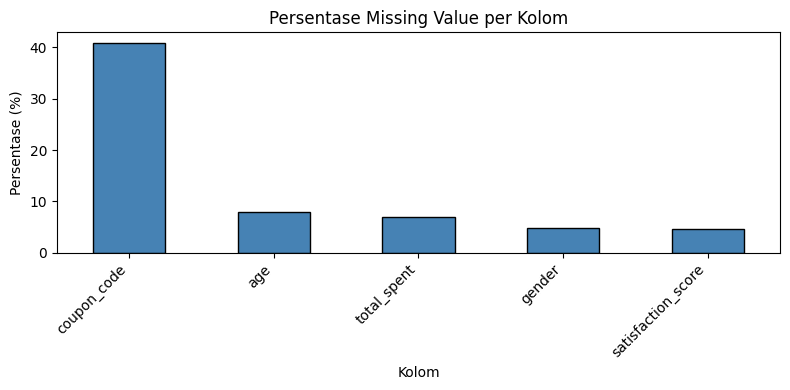

In [5]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print('Persentase Missing Value:')
print(missing_pct.to_string())

plt.figure(figsize=(8, 4))
missing_pct.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.5 Distribusi Variabel Target (Churn)

> **Penjelasan:** Cek distribusi kelas target untuk lihat apakah dataset balanced atau imbalanced. Ini penting karena kalau imbalanced parah, model cenderung bias ke kelas mayoritas.

Distribusi Churn:
  0 (Tidak Churn): 12702 (84.7%)
  1 (Churn)      : 2298 (15.3%)


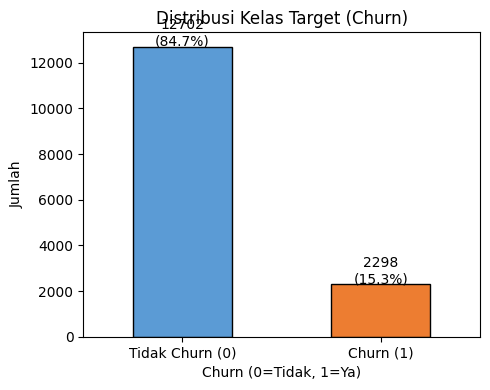

In [6]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('Distribusi Churn:')
print(f'  0 (Tidak Churn): {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'  1 (Churn)      : {churn_counts[1]} ({churn_pct[1]:.1f}%)')

plt.figure(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['#5B9BD5', '#ED7D31'], edgecolor='black')
plt.title('Distribusi Kelas Target (Churn)')
plt.xlabel('Churn (0=Tidak, 1=Ya)')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Tidak Churn (0)', 'Churn (1)'], rotation=0)
for i, v in enumerate(churn_counts):
    plt.text(i, v + 50, f'{v}\n({churn_pct.iloc[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

### 1.6 Distribusi Fitur Numerik

> **Penjelasan:** Histogram tiap fitur numerik dipakai untuk lihat bentuk sebarannya — apakah normal, skewed (miring), atau ada pola aneh seperti banyak nilai 0 menumpuk. Ini berguna buat nentuin nanti perlu transformasi atau tidak, dan kenapa median dipilih (bukan mean) untuk imputasi nanti.

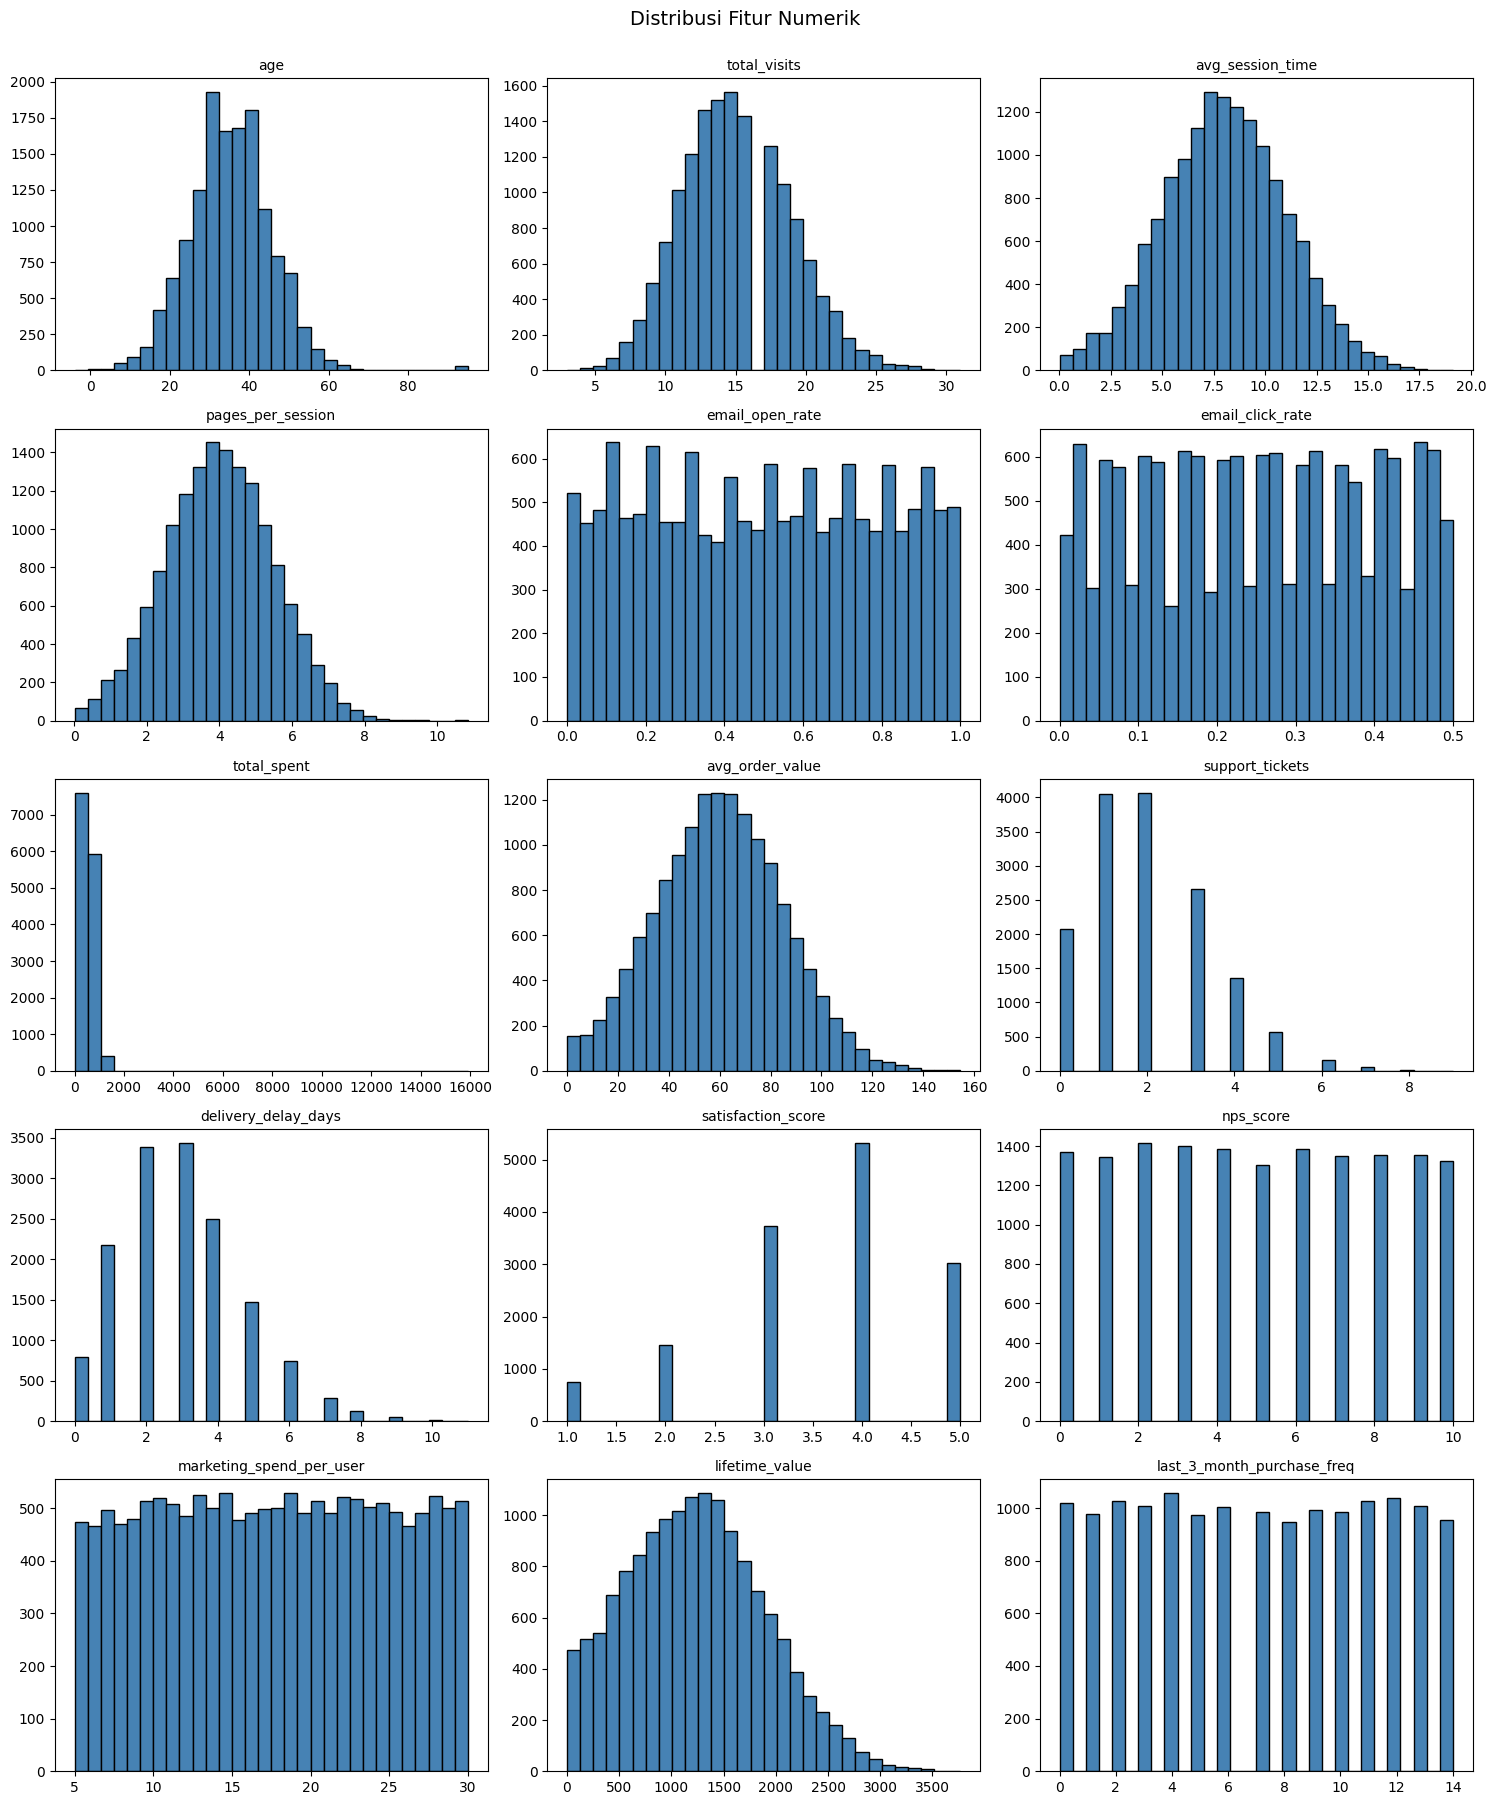

In [7]:
num_features = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                'email_open_rate', 'email_click_rate', 'total_spent',
                'avg_order_value', 'support_tickets', 'delivery_delay_days',
                'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
                'lifetime_value', 'last_3_month_purchase_freq']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### 1.7 Analisis Fitur Kategorikal vs Churn

> **Penjelasan:** Stacked bar chart dipakai untuk lihat proporsi churn di tiap kategori (bukan jumlah mentah, supaya fair walaupun jumlah sampel per kategori berbeda-beda). Kalau ada kategori dengan churn rate jauh lebih tinggi dari yang lain, itu sinyal kuat fitur tersebut berpengaruh ke churn.

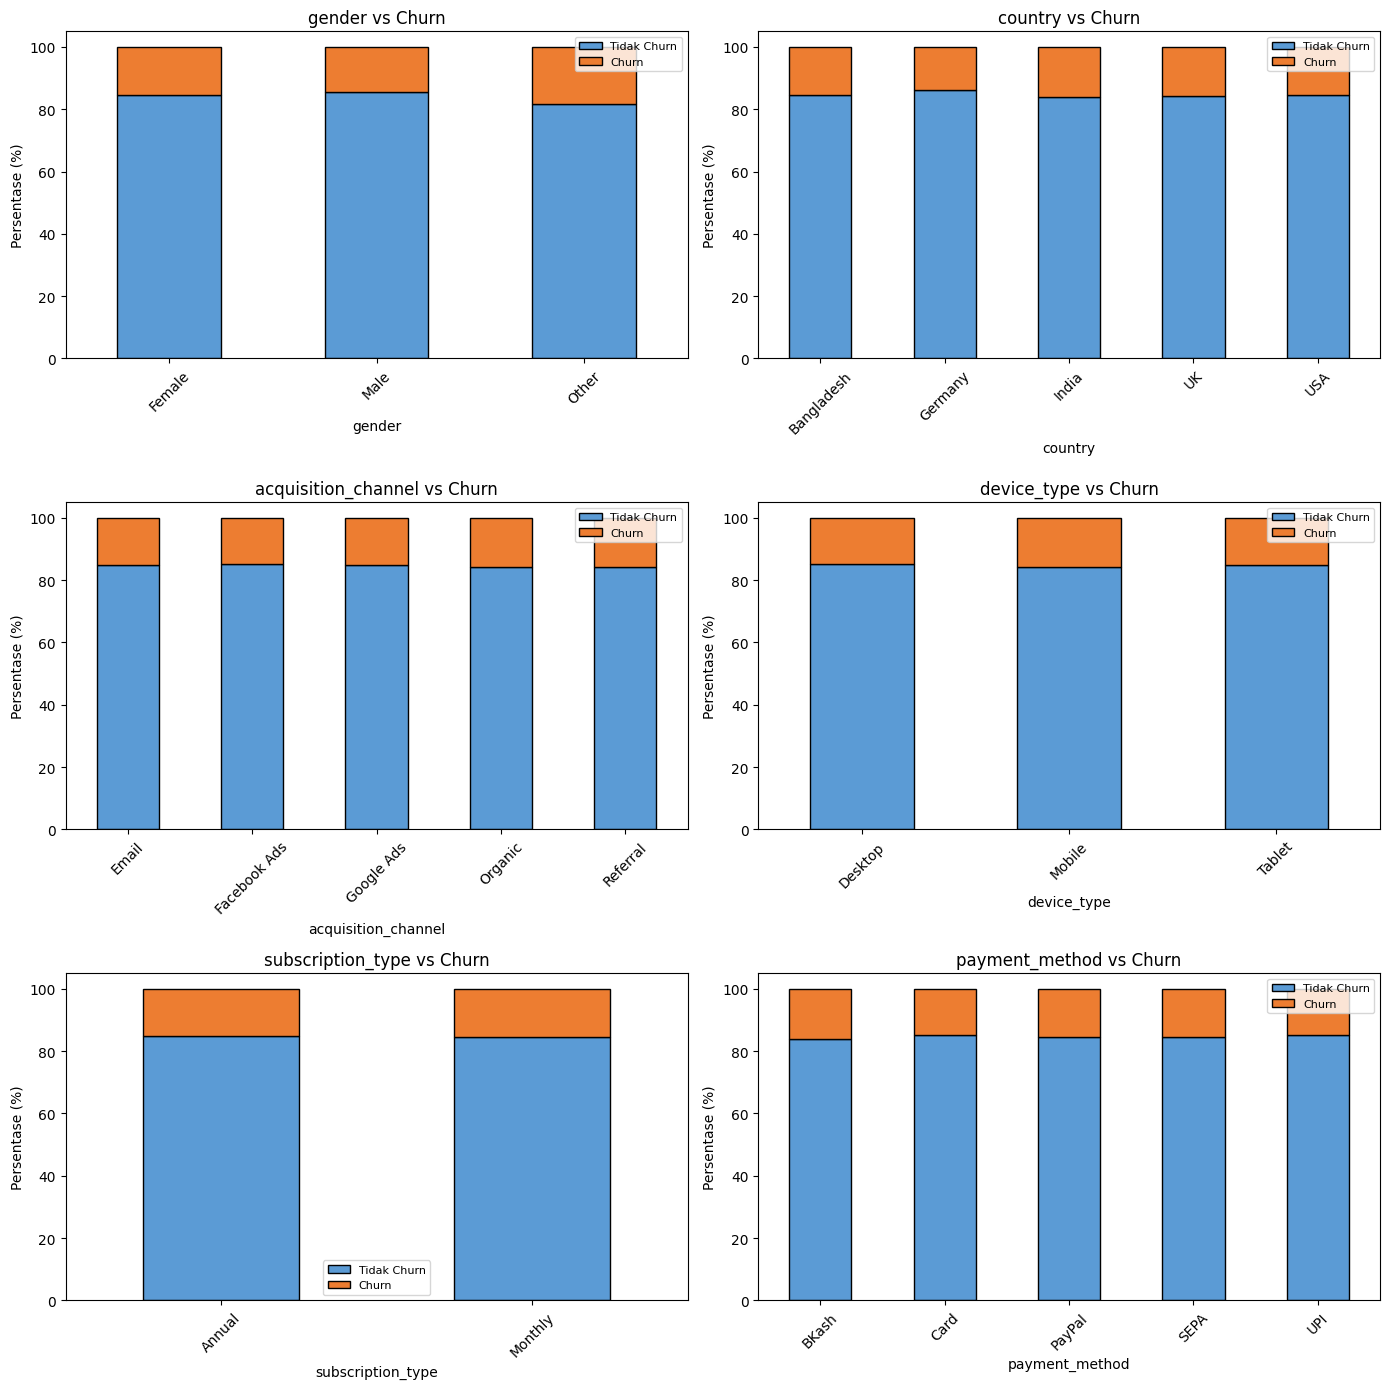

=== Churn Rate per Kategori ===

--- gender ---
gender
Female    15.50
Male      14.63
Other     18.44

--- country ---
country
Bangladesh    15.55
Germany       13.93
India         15.93
UK            15.80
USA           15.43

--- acquisition_channel ---
acquisition_channel
Email           14.97
Facebook Ads    14.81
Google Ads      15.16
Organic         15.88
Referral        15.78

--- device_type ---
device_type
Desktop    14.90
Mobile     15.83
Tablet     15.23

--- subscription_type ---
subscription_type
Annual     15.09
Monthly    15.54

--- payment_method ---
payment_method
BKash     16.09
Card      14.87
PayPal    15.37
SEPA      15.57
UPI       14.72



In [8]:
cat_features = ['gender', 'country', 'acquisition_channel', 'device_type',
                'subscription_type', 'payment_method']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    crosstab = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=axes[i],
                  color=['#5B9BD5', '#ED7D31'], edgecolor='black')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['Tidak Churn', 'Churn'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('=== Churn Rate per Kategori ===\n')
for col in cat_features:
    print(f'--- {col} ---')
    churn_rate = df.groupby(col)['churn'].mean() * 100
    print(churn_rate.round(2).to_string())
    print()

In [9]:
cat_features = ['gender', 'country', 'city', 'acquisition_channel', 'device_type',
                'subscription_type', 'payment_method']

for col in cat_features:
  print(f"Name: {col}")
  print(df[col].value_counts())


Name: gender
gender
Male      6844
Female    6686
Other      732
Name: count, dtype: int64
Name: country
country
Germany       3072
India         3014
Bangladesh    2984
USA           2975
UK            2955
Name: count, dtype: int64
Name: city
city
London      2236
Mumbai      2184
Dhaka       2178
New York    2135
Delhi       2128
Berlin      2075
Hamburg     2064
Name: count, dtype: int64
Name: acquisition_channel
acquisition_channel
Organic         3055
Google Ads      3047
Facebook Ads    3024
Referral        2941
Email           2933
Name: count, dtype: int64
Name: device_type
device_type
Tablet     5043
Mobile     4997
Desktop    4960
Name: count, dtype: int64
Name: subscription_type
subscription_type
Monthly    7666
Annual     7334
Name: count, dtype: int64
Name: payment_method
payment_method
UPI       3105
PayPal    3005
SEPA      2986
BKash     2971
Card      2933
Name: count, dtype: int64


### 1.8 Heatmap Korelasi Fitur Numerik + Top 10 Korelasi dengan Churn

> **Penjelasan:** Heatmap korelasi digunakan untuk lihat hubungan antar fitur numerik. Korelasi tinggi antara dua fitur (>0.8 atau <-0.8) bisa mengindikasikan multikolinearitas yang perlu diperhatikan saat modeling. Top 10 korelasi terhadap target diambil pakai nilai absolut untuk ranking, tapi ditampilkan dengan tanda asli (+/-) supaya tahu arah hubungannya — korelasi negatif kuat sama pentingnya dengan korelasi positif.

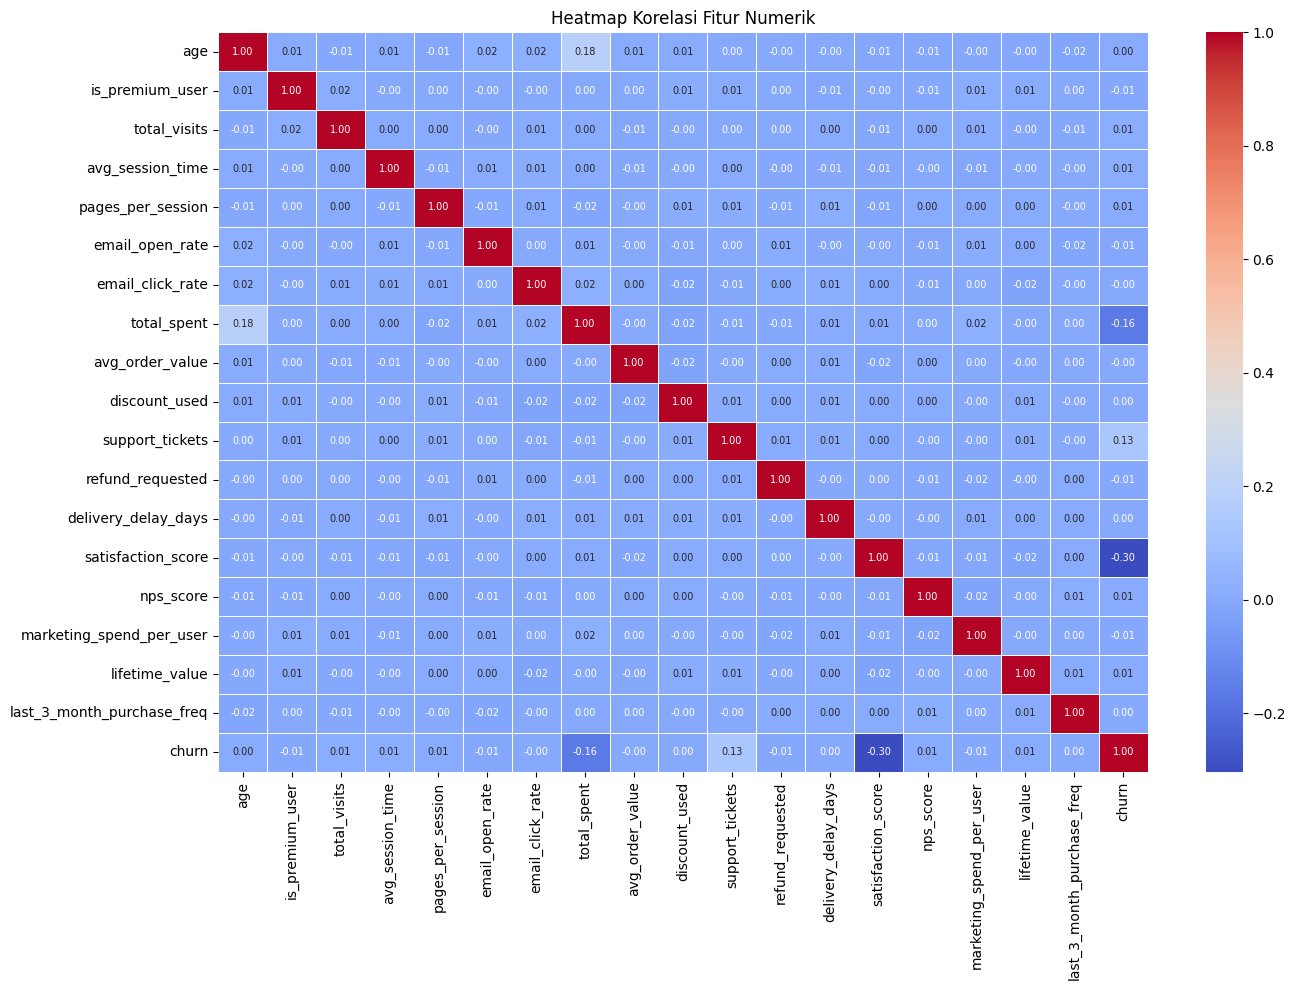

=== Top 10 Fitur Paling Berkorelasi dengan Churn ===
satisfaction_score         -0.303588
total_spent                -0.163279
support_tickets             0.127910
total_visits                0.013212
avg_session_time            0.012198
email_open_rate            -0.008439
marketing_spend_per_user   -0.007315
refund_requested           -0.006959
lifetime_value              0.006250
pages_per_session           0.005871


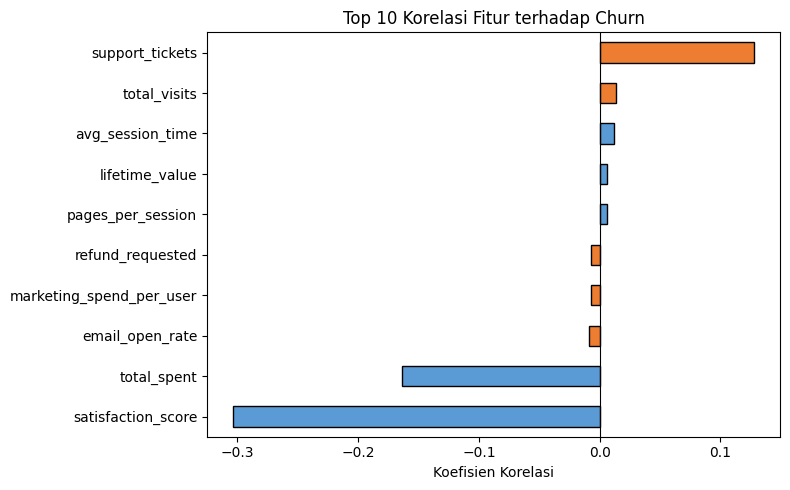

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

corr_with_churn = corr_matrix['churn'].drop('churn')
top10_corr = corr_with_churn.abs().sort_values(ascending=False).head(10)
top10_with_sign = corr_with_churn[top10_corr.index]

print('=== Top 10 Fitur Paling Berkorelasi dengan Churn ===')
print(top10_with_sign.to_string())

plt.figure(figsize=(8, 5))
colors = ['#ED7D31' if v > 0 else '#5B9BD5' for v in top10_with_sign]
top10_with_sign.sort_values().plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 10 Korelasi Fitur terhadap Churn')
plt.xlabel('Koefisien Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 1.9 Deteksi Outlier (Boxplot + Metode IQR)

> **Penjelasan:** Boxplot dipakai untuk inspeksi visual cepat, sedangkan perhitungan IQR (Interquartile Range) dipakai untuk dapat angka pasti jumlah outlier per kolom. IQR dipilih karena tidak butuh asumsi distribusi normal — beberapa fitur seperti `total_spent` dan `lifetime_value` cenderung skewed, jadi metode berbasis kuartil lebih cocok dibanding metode berbasis standar deviasi (Z-Score). Hasil di sini jadi dasar keputusan capping/clipping di bagian preprocessing nanti.

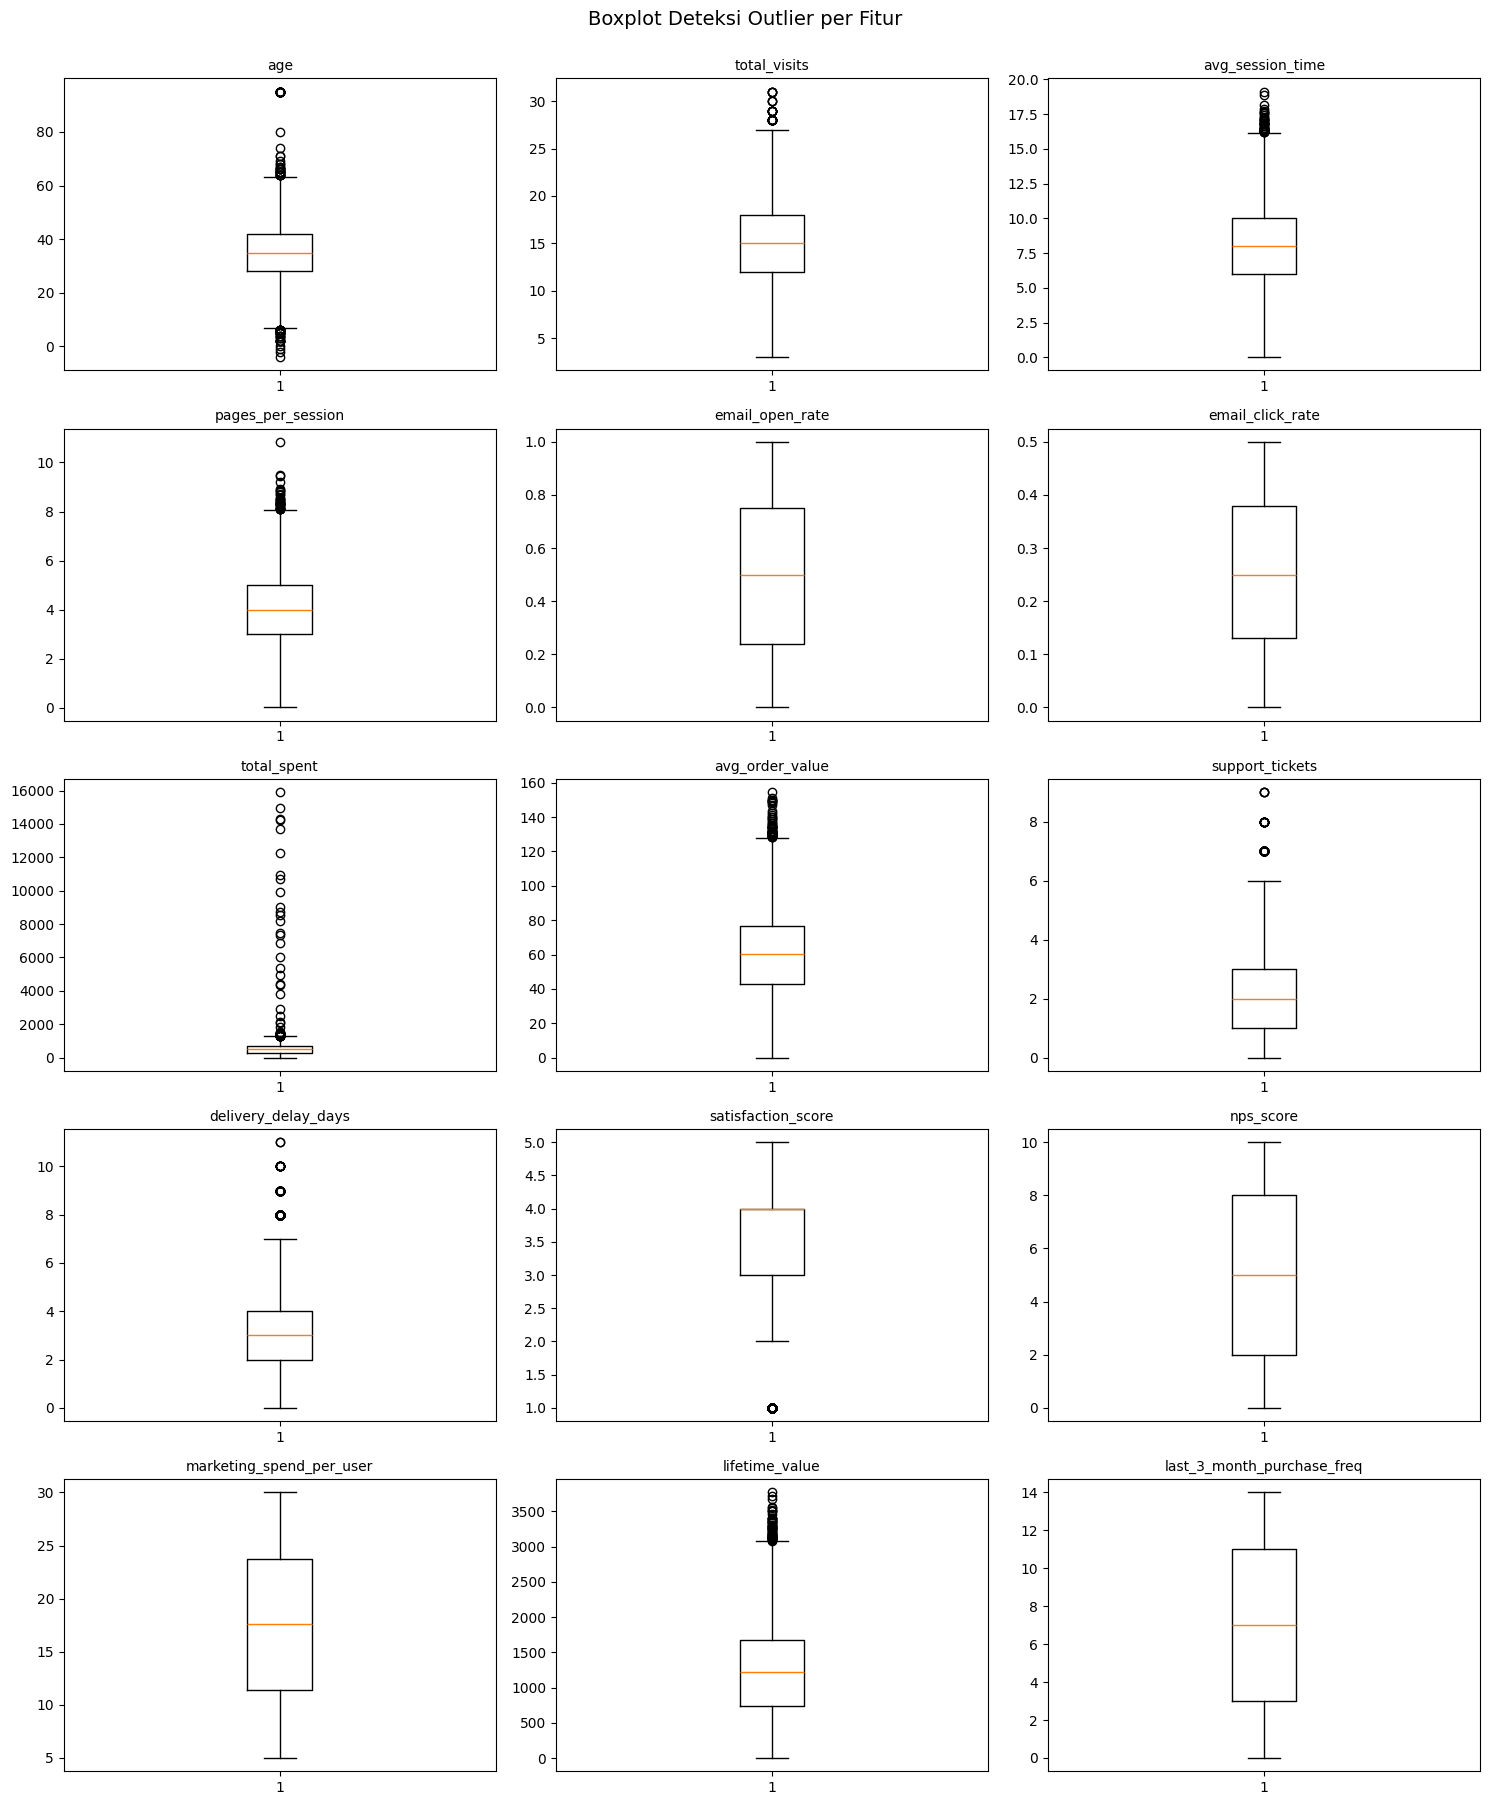

=== Jumlah Outlier per Kolom (Metode IQR) ===

                     kolom  jumlah_outlier  persentase  batas_bawah  batas_atas
        satisfaction_score             753        5.02         1.50        5.50
       delivery_delay_days             184        1.23        -1.00        7.00
                       age              89        0.59         7.00       63.00
           support_tickets              79        0.53        -2.00        6.00
               total_spent              78        0.52      -302.51     1305.34
            lifetime_value              56        0.37      -663.54     3082.70
           avg_order_value              54        0.36        -7.75      127.67
          avg_session_time              45        0.30        -0.15       16.19
              total_visits              39        0.26         3.00       27.00
         pages_per_session              33        0.22        -0.05        8.05
           email_open_rate               0        0.00        -0.52      

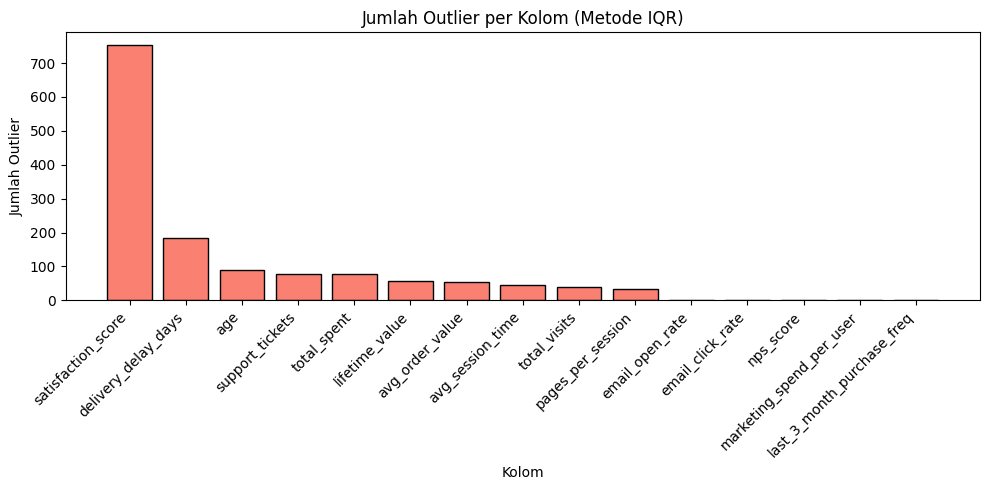

In [11]:
cols_outlier = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                'email_open_rate', 'email_click_rate', 'total_spent',
                'avg_order_value', 'support_tickets', 'delivery_delay_days',
                'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
                'lifetime_value', 'last_3_month_purchase_freq']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col, fontsize=10)

for j in range(len(cols_outlier), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplot Deteksi Outlier per Fitur', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

print('=== Jumlah Outlier per Kolom (Metode IQR) ===\n')
outlier_summary = []

for col in cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'kolom': col,
        'jumlah_outlier': outlier_count,
        'persentase': round(outlier_pct, 2),
        'batas_bawah': round(lower, 2),
        'batas_atas': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('jumlah_outlier', ascending=False)
print(outlier_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(outlier_df['kolom'], outlier_df['jumlah_outlier'],
        color='salmon', edgecolor='black')
plt.title('Jumlah Outlier per Kolom (Metode IQR)')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# BAGIAN 2: DIRECT MODELING (Tanpa Preprocessing)

> **Catatan penting:** Pada skenario ini, model dilatih **langsung** tanpa preprocessing apapun. Hanya kolom numerik yang bisa dipakai karena model sklearn tidak bisa terima data string secara langsung. Ini sengaja dibuat sebagai baseline untuk dibandingkan dengan skenario berikutnya.

### 2.1 Persiapan Fitur & Target

In [12]:
num_cols_direct = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_direct = [c for c in num_cols_direct if c not in ['customer_id', 'churn']]

X_direct = df[num_cols_direct].copy()
y_direct = df['churn'].copy()

X_direct = X_direct.fillna(X_direct.median())

print('Fitur yang digunakan untuk Direct Modeling:')
print(num_cols_direct)
print(f'\nShape X: {X_direct.shape}')
print(f'Shape y: {y_direct.shape}')

Fitur yang digunakan untuk Direct Modeling:
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Shape X: (15000, 18)
Shape y: (15000,)


### 2.2 Train-Test Split

In [13]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

print(f'Train size: {X_train_d.shape[0]} sampel')
print(f'Test size : {X_test_d.shape[0]} sampel')
print(f'\nDistribusi churn di train: {y_train_d.value_counts().to_dict()}')
print(f'Distribusi churn di test : {y_test_d.value_counts().to_dict()}')

Train size: 12000 sampel
Test size : 3000 sampel

Distribusi churn di train: {0: 10162, 1: 1838}
Distribusi churn di test : {0: 2540, 1: 460}


### 2.3 Fungsi Evaluasi Model

In [14]:
def evaluasi_model(model_name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f'--- {model_name} ---')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Actual: 0', 'Actual: 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

all_results = []

### 2.4 Model 1: Logistic Regression (Konvensional)

> **Kenapa Logistic Regression?**  
> Dipilih sebagai model konvensional karena interpretasinya mudah, cocok untuk klasifikasi biner, dan jadi baseline yang baik.

--- LR - Direct ---
Accuracy  : 0.8437
Precision : 0.4667
Recall    : 0.1370
F1-Score  : 0.2118


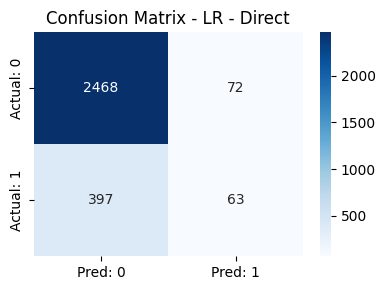

In [15]:
lr_direct = LogisticRegression(random_state=42, max_iter=1000)
lr_direct.fit(X_train_d, y_train_d)
y_pred_lr_d = lr_direct.predict(X_test_d)

result = evaluasi_model('LR - Direct', y_test_d, y_pred_lr_d)
result['skenario'] = 'Direct'
all_results.append(result)

### 2.5 Model 2: Random Forest (Ensemble Bagging)

> **Kenapa Random Forest?**  
> Random Forest adalah ensemble bagging yang membangun banyak decision tree secara paralel dengan bootstrap sampling. Lebih robust dari single decision tree dan tahan terhadap overfitting.

--- RF - Direct ---
Accuracy  : 0.8470
Precision : 0.5015
Recall    : 0.3696
F1-Score  : 0.4255


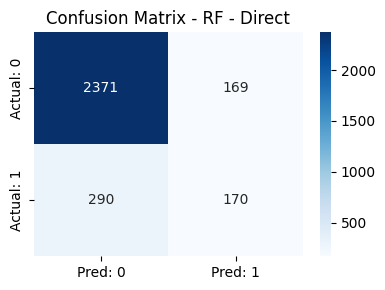

In [16]:
rf_direct = RandomForestClassifier(random_state=42, n_estimators=100)
rf_direct.fit(X_train_d, y_train_d)
y_pred_rf_d = rf_direct.predict(X_test_d)

result = evaluasi_model('RF - Direct', y_test_d, y_pred_rf_d)
result['skenario'] = 'Direct'
all_results.append(result)

### 2.6 Model 3: Voting Classifier (Ensemble Voting)

> **Kenapa VotingClassifier dengan LR + SVM + KNN?**  
> VotingClassifier menggabungkan beberapa model konvensional (hard voting = mayoritas suara). Ketiganya punya pendekatan berbeda (linear, kernel, distance-based) sehingga saling melengkapi.

--- Voting - Direct ---
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.0326
F1-Score  : 0.0612


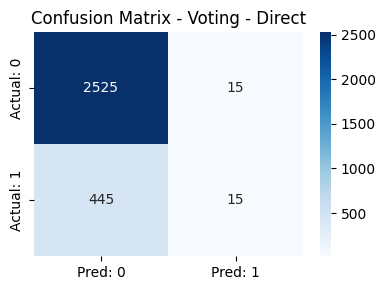

In [17]:
estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(random_state=42, probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

voting_direct = VotingClassifier(estimators=estimators, voting='hard')
voting_direct.fit(X_train_d, y_train_d)
y_pred_vot_d = voting_direct.predict(X_test_d)

result = evaluasi_model('Voting - Direct', y_test_d, y_pred_vot_d)
result['skenario'] = 'Direct'
all_results.append(result)

---
# BAGIAN 3: MODELING DENGAN PREPROCESSING

### 3.1 Preprocessing - Handling Missing Value

> **Kenapa imputasi bukan drop?**  
> Dataset punya 15.000 baris. Missing value terbesar di `coupon_code` (40.9%) tapi kolom itu akan dihapus karena hanya 3 kategori dan informasinya sudah tercermin di fitur lain. Untuk kolom lain (`gender`, `age`, `total_spent`, `satisfaction_score`) lebih baik imputasi daripada hapus baris karena drop baris akan mengurangi data secara signifikan.

> **Kenapa median untuk numerik?**  
> Median lebih robust terhadap outlier dibanding mean. Sesuai temuan di EDA (bagian 1.6 & 1.9), beberapa fitur seperti `total_spent` punya distribusi skewed dan outlier, jadi mean bisa kegeser jauh dari nilai tipikal.

> **Kenapa mode untuk kategorik?**  
> Untuk `gender` (kategorik), mode (nilai paling sering muncul) adalah pilihan logis karena tidak ada cara yang meaningful untuk merata-ratakan data kategorik.

In [18]:
df_prep = df.copy()

print('=== Sebelum penanganan missing value ===')
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

=== Sebelum penanganan missing value ===
gender                 738
age                   1200
total_spent           1050
coupon_code           6133
satisfaction_score     702
dtype: int64


In [19]:
df_prep['age'] = df_prep['age'].fillna(df_prep['age'].median())
df_prep['total_spent'] = df_prep['total_spent'].fillna(df_prep['total_spent'].median())
df_prep['satisfaction_score'] = df_prep['satisfaction_score'].fillna(df_prep['satisfaction_score'].median())

df_prep['gender'] = df_prep['gender'].fillna(df_prep['gender'].mode()[0])

print('Setelah imputasi numerik & kategorik:')
print(df_prep[['age', 'total_spent', 'satisfaction_score', 'gender']].isnull().sum())

Setelah imputasi numerik & kategorik:
age                   0
total_spent           0
satisfaction_score    0
gender                0
dtype: int64


### 3.2 Preprocessing - Handling Duplikasi

In [20]:
dup_count = df_prep.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    df_prep = df_prep.drop_duplicates()
    print(f'Baris duplikat dihapus. Shape sekarang: {df_prep.shape}')
else:
    print('Tidak ada duplikat, tidak ada yang dihapus.')

Jumlah baris duplikat: 0
Tidak ada duplikat, tidak ada yang dihapus.


### 3.3 Preprocessing - Handling Outlier (IQR Method)

> **Kenapa IQR dan bukan Z-Score?**  
> Konsisten dengan analisis di EDA (1.9) — IQR tidak bergantung pada asumsi distribusi normal, dan beberapa fitur di dataset ini terbukti skewed.

> **Kenapa clip (capping) bukan drop?**  
> Kalau outlier di-drop, bisa kehilangan banyak data. Capping ke nilai batas IQR lebih aman karena tetap mempertahankan jumlah data tapi mengurangi efek nilai ekstrem.

In [21]:
cols_outlier = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                'email_open_rate', 'email_click_rate', 'total_spent',
                'avg_order_value', 'support_tickets', 'delivery_delay_days',
                'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
                'lifetime_value', 'last_3_month_purchase_freq']

for col in cols_outlier:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    if outlier_count > 0:
        print(f'{col}: {outlier_count} outlier -> di-clip ke [{lower:.2f}, {upper:.2f}]')
        df_prep[col] = df_prep[col].clip(lower=lower, upper=upper)

print('\nOutlier handling selesai.')

age: 218 outlier -> di-clip ke [11.00, 59.00]
total_visits: 39 outlier -> di-clip ke [3.00, 27.00]
avg_session_time: 45 outlier -> di-clip ke [-0.15, 16.19]
pages_per_session: 33 outlier -> di-clip ke [-0.05, 8.05]
total_spent: 119 outlier -> di-clip ke [-232.53, 1233.57]
avg_order_value: 54 outlier -> di-clip ke [-7.75, 127.67]
support_tickets: 79 outlier -> di-clip ke [-2.00, 6.00]
delivery_delay_days: 184 outlier -> di-clip ke [-1.00, 7.00]
satisfaction_score: 753 outlier -> di-clip ke [1.50, 5.50]
lifetime_value: 56 outlier -> di-clip ke [-663.54, 3082.70]

Outlier handling selesai.


### 3.4 Preprocessing - Feature Engineering dari Tanggal

> **Kenapa extract tenure dan recency?**  
> Kolom `signup_date` dan `last_purchase_date` dalam format string tidak bisa langsung dipakai model. Dengan mengekstrak *tenure* (berapa lama jadi pelanggan) dan *recency* (berapa hari sejak pembelian terakhir), kita mendapat informasi yang lebih bermakna untuk prediksi churn. Pelanggan lama yang sudah lama tidak belanja (recency tinggi) cenderung lebih berisiko churn.

In [22]:
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'])
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'])

ref_date = df_prep['last_purchase_date'].max()

df_prep['tenure_days'] = (ref_date - df_prep['signup_date']).dt.days
df_prep['recency_days'] = (ref_date - df_prep['last_purchase_date']).dt.days

print('Fitur baru dari tanggal berhasil dibuat:')
print(df_prep[['tenure_days', 'recency_days']].describe())

Fitur baru dari tanggal berhasil dibuat:
       tenure_days  recency_days
count  15000.00000  15000.000000
mean     664.09300    399.301867
std      290.06906    231.520502
min      165.00000      0.000000
25%      413.00000    197.000000
50%      661.00000    397.000000
75%      918.00000    602.000000
max     1164.00000    799.000000


### 3.5 Preprocessing - Hapus Fitur Tidak Relevan

> **Kenapa customer_id dihapus?**  
> ID unik tidak punya nilai prediktif. Kalau ikut dilatih, model bisa overfit ke ID tertentu.

> **Kenapa signup_date dan last_purchase_date dihapus?**  
> Sudah dikonversi jadi fitur numerik (tenure_days dan recency_days). Raw datetime tidak bisa langsung dipakai model.

> **Kenapa coupon_code dihapus?**  
> Kolom ini punya 40.9% missing value (hampir separuh data). Selain itu hanya ada 3 nilai unik (NEW20, SALE15, REF10) dan informasinya tumpang tindih dengan `discount_used`.

> **Kenapa city dihapus, tapi country dipertahankan?**  
> `city` adalah fitur high-cardinality (terlalu banyak nilai unik kota), kalau di-One-Hot-Encode akan membuat jumlah kolom meledak (curse of dimensionality) padahal kontribusinya ke prediksi churn tidak jelas. `country` jumlah kategorinya cuma 5, jadi masih aman dan layak dipertahankan sebagai fitur kategorikal yang akan di-One-Hot-Encode.

In [23]:
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city']
df_prep = df_prep.drop(columns=drop_cols)

print(f'Kolom yang dihapus: {drop_cols}')
print(f'Shape setelah drop: {df_prep.shape}')
print(f'Kolom tersisa: {list(df_prep.columns)}')

Kolom yang dihapus: ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city']
Shape setelah drop: (15000, 27)
Kolom tersisa: ['gender', 'age', 'country', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn', 'tenure_days', 'recency_days']


### 3.6 Preprocessing - Encoding Fitur Kategorikal

> **Kenapa One-Hot Encoding untuk fitur nominal, bukan Label Encoding?**  
> Fitur seperti `gender`, `country`, `acquisition_channel`, `device_type`, dan `payment_method` adalah fitur **nominal** — kategori-kategorinya tidak punya urutan logis. Kalau dipaksa pakai Label Encoding (Email=0, Organic=1, Facebook Ads=2, dst), model terutama yang berbasis linear (Logistic Regression, SVM) akan "membaca" angka itu sebagai punya hubungan matematis/urutan, padahal itu cuma label sembarang. Ini disebut *fabricated ordinal relationship* dan bisa menyesatkan model. One-Hot Encoding (OHE) menghindari masalah ini karena tiap kategori jadi kolom biner terpisah (0/1), tidak ada asumsi urutan sama sekali.

> **Kenapa subscription_type tetap pakai Label Encoding?**  
> Karena `subscription_type` hanya punya 2 nilai (Annual/Monthly), Label Encoding pada kasus biner secara matematis **identik** dengan One-Hot Encoding (cuma beda nama kolom dan arah angka), jadi tidak ada risiko fabricated ordinal relationship. Tidak perlu OHE untuk kasus biner — cukup 1 kolom 0/1.

> **Kenapa drop_first=True saat OHE?**  
> Ini untuk menghindari *dummy variable trap* — yaitu kondisi ketika salah satu kategori bisa ditebak otomatis dari kategori lain (misal kalau gender_Male=0 dan gender_Other=0, otomatis gender_Female=1). Kondisi ini menyebabkan multikolinearitas sempurna yang mengganggu model linear seperti Logistic Regression. Dengan drop_first, satu kategori dijadikan baseline (tidak dibuatkan kolom), dan informasinya tetap implisit lewat kombinasi kolom lain.

In [24]:
binary_cols = ['subscription_type']

le = LabelEncoder()
le_dict = {}
for col in binary_cols:
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    le_dict[col] = le
    print(f'{col}: Label Encoded -> nilai unik {df_prep[col].unique()}')

nominal_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']

df_prep = pd.get_dummies(df_prep, columns=nominal_cols, drop_first=True)

print(f'\nShape setelah One-Hot Encoding: {df_prep.shape}')
print('\nContoh kolom hasil OHE:')
print([c for c in df_prep.columns if any(nc in c for nc in nominal_cols)])

subscription_type: Label Encoded -> nilai unik [0 1]

Shape setelah One-Hot Encoding: (15000, 38)

Contoh kolom hasil OHE:
['gender_Male', 'gender_Other', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'acquisition_channel_Facebook Ads', 'acquisition_channel_Google Ads', 'acquisition_channel_Organic', 'acquisition_channel_Referral', 'device_type_Mobile', 'device_type_Tablet', 'payment_method_Card', 'payment_method_PayPal', 'payment_method_SEPA', 'payment_method_UPI']


### 3.7 Set Fitur & Target, Kemudian Train-Test Split

In [25]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

print(f'Jumlah fitur setelah OHE: {X_prep.shape[1]}')
print('Daftar fitur:')
print(list(X_prep.columns))

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

print(f'\nTrain: {X_train_p.shape[0]} | Test: {X_test_p.shape[0]}')

Jumlah fitur setelah OHE: 37
Daftar fitur:
['age', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'tenure_days', 'recency_days', 'gender_Male', 'gender_Other', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'acquisition_channel_Facebook Ads', 'acquisition_channel_Google Ads', 'acquisition_channel_Organic', 'acquisition_channel_Referral', 'device_type_Mobile', 'device_type_Tablet', 'payment_method_Card', 'payment_method_PayPal', 'payment_method_SEPA', 'payment_method_UPI']

Train: 12000 | Test: 3000


### 3.8 Scaling Fitur

> **Kenapa scaling dilakukan SETELAH split?**  
> Ini untuk mencegah **data leakage**. Kalau scaling dilakukan sebelum split, informasi dari data test (nilai min/max/mean dari seluruh dataset) ikut masuk ke proses fitting scaler. Akibatnya model "bocor" - seolah-olah sudah tahu distribusi data test padahal belum. Scaler di-fit HANYA dari X_train, lalu di-transform ke X_test.

> **Kenapa StandardScaler?**  
> StandardScaler mengubah data ke distribusi dengan mean=0 dan std=1. Cocok untuk algoritma yang sensitif terhadap skala seperti Logistic Regression, SVM, dan KNN. Kolom hasil One-Hot Encoding (isinya 0/1) ikut di-scale juga, tidak masalah karena tetap mempertahankan informasi yang sama, hanya rentang nilainya berubah.

In [26]:
scaler = StandardScaler()

X_train_p_scaled = scaler.fit_transform(X_train_p)
X_test_p_scaled = scaler.transform(X_test_p)

print('Scaling selesai.')
print(f'Mean setelah scaling (harusnya ~0): {X_train_p_scaled.mean(axis=0)[:3].round(4)}')
print(f'Std setelah scaling (harusnya ~1) : {X_train_p_scaled.std(axis=0)[:3].round(4)}')

Scaling selesai.
Mean setelah scaling (harusnya ~0): [ 0.  0. -0.]
Std setelah scaling (harusnya ~1) : [1. 1. 1.]


### 3.9 Handling Class Imbalance dengan SMOTE

> **Kenapa SMOTE diterapkan di sini?**  
> Dari EDA (1.5) diketahui dataset imbalanced: ~84.7% tidak churn vs ~15.3% churn. Tanpa penanganan, model cenderung bias ke kelas mayoritas (tidak churn) dan mengabaikan kelas minoritas. SMOTE (Synthetic Minority Oversampling Technique) membuat sampel sintetis untuk kelas minoritas berdasarkan interpolasi KNN antar sampel yang sudah ada — bukan sekadar menduplikasi.

> **Kenapa SMOTE diterapkan SETELAH scaling dan SETELAH split?**  
> SMOTE harus diterapkan **hanya pada data train**, bukan test. Kalau diterapkan sebelum split, sampel sintetis bisa "bocor" ke data test sehingga evaluasi model menjadi terlalu optimis (data leakage). Scaling dilakukan lebih dulu supaya interpolasi SMOTE bekerja pada skala yang sama.

> **X_test tetap pakai X_test_p_scaled tanpa SMOTE** — karena test set merepresentasikan data nyata yang distribusinya tidak kita ubah.

=== Distribusi kelas SEBELUM SMOTE (train) ===
churn
0    10162
1     1838
Name: count, dtype: int64
Rasio imbalance: 5.53:1

=== Distribusi kelas SETELAH SMOTE (train) ===
churn
1    10162
0    10162
Name: count, dtype: int64
Shape X_train setelah SMOTE: (20324, 37)


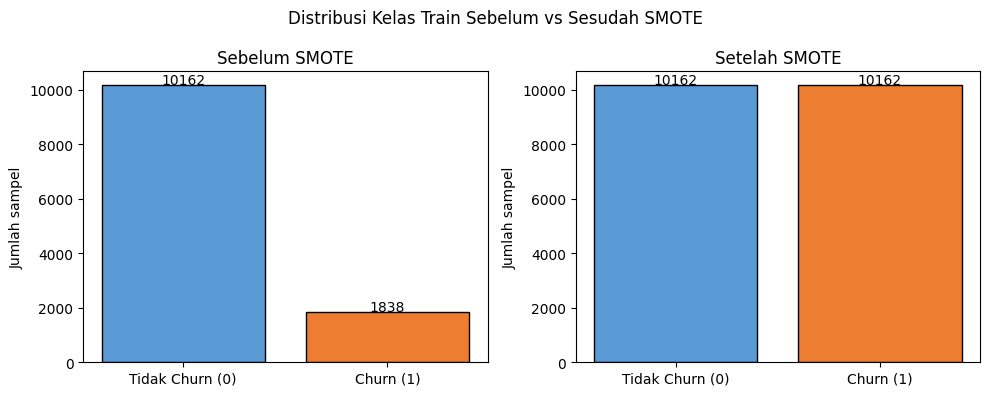


SMOTE selesai. X_train_smote dan y_train_smote siap digunakan untuk training.


In [27]:
print('=== Distribusi kelas SEBELUM SMOTE (train) ===')
print(y_train_p.value_counts())
print(f'Rasio imbalance: {y_train_p.value_counts()[0]/y_train_p.value_counts()[1]:.2f}:1')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_p_scaled, y_train_p)

print('\n=== Distribusi kelas SETELAH SMOTE (train) ===')
import pandas as pd
print(pd.Series(y_train_smote).value_counts())
print(f'Shape X_train setelah SMOTE: {X_train_smote.shape}')

# Visualisasi perbandingan sebelum & sesudah SMOTE
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = y_train_p.value_counts()
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], before.values,
            color=['#5B9BD5', '#ED7D31'], edgecolor='black')
axes[0].set_title('Sebelum SMOTE')
axes[0].set_ylabel('Jumlah sampel')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 50, str(v), ha='center')

after = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Tidak Churn (0)', 'Churn (1)'], after.values,
            color=['#5B9BD5', '#ED7D31'], edgecolor='black')
axes[1].set_title('Setelah SMOTE')
axes[1].set_ylabel('Jumlah sampel')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 50, str(v), ha='center')

plt.suptitle('Distribusi Kelas Train Sebelum vs Sesudah SMOTE')
plt.tight_layout()
plt.show()

print('\nSMOTE selesai. X_train_smote dan y_train_smote siap digunakan untuk training.')

### 3.10 Model 4: Logistic Regression + Preprocessing + SMOTE


--- LR - Preprocessing ---
Accuracy  : 0.7507
Precision : 0.3481
Recall    : 0.7174
F1-Score  : 0.4688


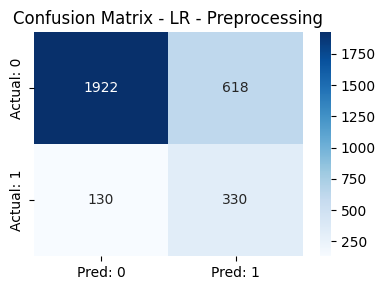

In [28]:
lr_prep = LogisticRegression(random_state=42, max_iter=1000)
lr_prep.fit(X_train_smote, y_train_smote)
y_pred_lr_p = lr_prep.predict(X_test_p_scaled)

result = evaluasi_model('LR - Preprocessing', y_test_p, y_pred_lr_p)
result['skenario'] = 'Preprocessing'
all_results.append(result)

### 3.11 Model 5: Random Forest + Preprocessing + SMOTE


--- RF - Preprocessing ---
Accuracy  : 0.8487
Precision : 0.5049
Recall    : 0.6674
F1-Score  : 0.5749


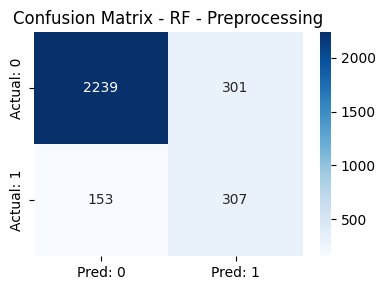

In [29]:
rf_prep = RandomForestClassifier(random_state=42, n_estimators=100)
rf_prep.fit(X_train_smote, y_train_smote)
y_pred_rf_p = rf_prep.predict(X_test_p_scaled)

result = evaluasi_model('RF - Preprocessing', y_test_p, y_pred_rf_p)
result['skenario'] = 'Preprocessing'
all_results.append(result)

### 3.12 Model 6: Voting Classifier + Preprocessing + SMOTE


--- Voting - Preprocessing ---
Accuracy  : 0.7920
Precision : 0.3978
Recall    : 0.6935
F1-Score  : 0.5055


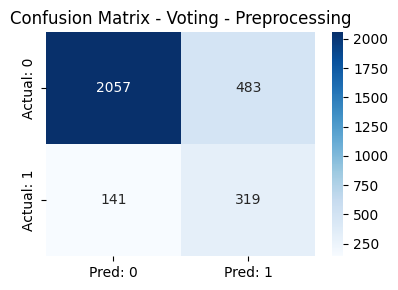

In [30]:
estimators_p = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(random_state=42, probability=True)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

voting_prep = VotingClassifier(estimators=estimators_p, voting='hard')
voting_prep.fit(X_train_smote, y_train_smote)
y_pred_vot_p = voting_prep.predict(X_test_p_scaled)

result = evaluasi_model('Voting - Preprocessing', y_test_p, y_pred_vot_p)
result['skenario'] = 'Preprocessing'
all_results.append(result)

---
# BAGIAN 4: HYPERPARAMETER TUNING & FEATURE SELECTION

### 4.1 Feature Importance Analysis

> **Kenapa pakai Random Forest untuk feature importance?**  
> Random Forest secara native menghitung *impurity-based feature importance* (Gini importance). Ini mengukur seberapa banyak setiap fitur berkontribusi dalam mengurangi impurity di split tree. Lebih reliable untuk data campuran (numerik + hasil OHE) dibanding hanya melihat correlation.

Top 15 Fitur Terpenting:
                   feature  importance
        satisfaction_score    0.271335
               total_spent    0.202825
           support_tickets    0.088273
       delivery_delay_days    0.029140
             discount_used    0.028586
                 nps_score    0.023722
               gender_Male    0.023686
           is_premium_user    0.023300
              total_visits    0.021360
last_3_month_purchase_freq    0.020129
  marketing_spend_per_user    0.020107
               tenure_days    0.019983
         subscription_type    0.019457
              recency_days    0.019148
          avg_session_time    0.018748


<Figure size 800x600 with 0 Axes>

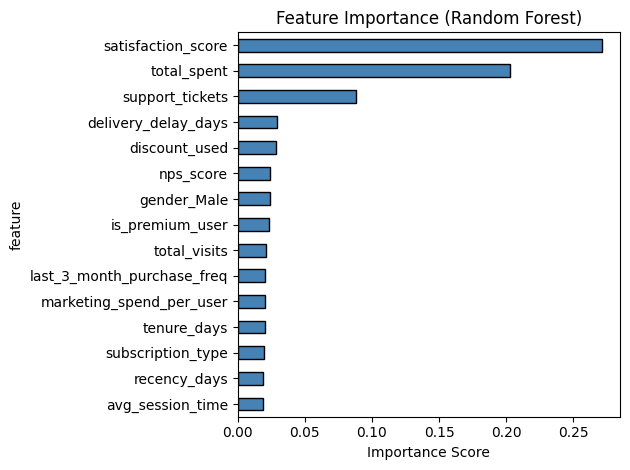

In [31]:
feature_names = X_prep.columns.tolist()
importances = rf_prep.feature_importances_

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 15 Fitur Terpenting:')
print(fi_df.head(15).to_string(index=False))

plt.figure(figsize=(8, 6))
fi_df.head(15).plot(kind='barh', x='feature', y='importance',
                    legend=False, color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2 Feature Selection

> **Kenapa pilih top-15 fitur?**  
> Berdasarkan grafik feature importance, ada beberapa fitur (termasuk sebagian hasil OHE seperti kategori negara/payment tertentu) dengan importance sangat rendah. Fitur-fitur ini tidak berkontribusi signifikan tapi menambah kompleksitas model. Memilih top-15 adalah trade-off antara informasi dan efisiensi model.

In [32]:
top_features = fi_df.head(15)['feature'].tolist()
print('Fitur yang dipilih untuk tuning:')
print(top_features)

# Buat index posisi untuk slice numpy array
feat_idx = [feature_names.index(f) for f in top_features]

# Data tuning dari hasil preprocessing + SMOTE (train) dan scaled test (test)
X_train_tune = X_train_smote[:, feat_idx]
X_test_tune = X_test_p_scaled[:, feat_idx]

# Untuk y_train tuning, pakai y yang sudah di-SMOTE
y_train_tune = y_train_smote

print(f'Shape X_train_tune: {X_train_tune.shape}')
print(f'Shape X_test_tune : {X_test_tune.shape}')
print(f'Distribusi y_train_tune: {pd.Series(y_train_tune).value_counts().to_dict()}')

Fitur yang dipilih untuk tuning:
['satisfaction_score', 'total_spent', 'support_tickets', 'delivery_delay_days', 'discount_used', 'nps_score', 'gender_Male', 'is_premium_user', 'total_visits', 'last_3_month_purchase_freq', 'marketing_spend_per_user', 'tenure_days', 'subscription_type', 'recency_days', 'avg_session_time']
Shape X_train_tune: (20324, 15)
Shape X_test_tune : (3000, 15)
Distribusi y_train_tune: {1: 10162, 0: 10162}


### 4.3 Hyperparameter Tuning - Logistic Regression

> **Kenapa RandomizedSearchCV bukan GridSearchCV?**  
> GridSearchCV mencoba semua kombinasi parameter (eksponensial). RandomizedSearchCV random sample kombinasi dalam jumlah yang kita tentukan (n_iter). Untuk dataset besar (15.000), ini lebih efisien waktu tanpa kehilangan banyak performa.

> **Kenapa parameter ini yang dipilih untuk LR?**  
> - `C`: regularization strength (trade-off underfitting vs overfitting)
> - `penalty`: jenis regularization (L1 lebih sparse, L2 lebih smooth)
> - `solver`: algoritma optimasi yang kompatibel dengan penalty-nya

Best params LR: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
Best F1 (CV)  : 0.7846
--- LR - Tuning ---
Accuracy  : 0.7500
Precision : 0.3486
Recall    : 0.7261
F1-Score  : 0.4711


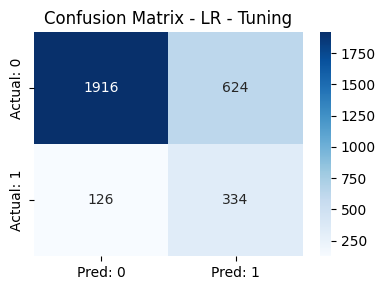

In [33]:
param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_base = LogisticRegression(random_state=42, max_iter=2000)
lr_search = RandomizedSearchCV(lr_base, param_lr, n_iter=10, cv=3,
                               scoring='f1', random_state=42, n_jobs=-1)
lr_search.fit(X_train_tune, y_train_tune)

print('Best params LR:', lr_search.best_params_)
print('Best F1 (CV)  :', lr_search.best_score_.round(4))

best_lr = lr_search.best_estimator_
y_pred_lr_t = best_lr.predict(X_test_tune)

result = evaluasi_model('LR - Tuning', y_test_p, y_pred_lr_t)
result['skenario'] = 'Tuning'
all_results.append(result)

### 4.4 Hyperparameter Tuning - Random Forest

> **Parameter yang di-tune:**  
> - `n_estimators`: jumlah tree (lebih banyak biasanya lebih baik tapi lebih lambat)
> - `max_depth`: kedalaman max tree (mencegah overfitting)
> - `min_samples_split`: minimum sample untuk split (regularisasi)
> - `min_samples_leaf`: minimum sample di leaf (regularisasi)
> - `max_features`: jumlah fitur yang dipertimbangkan tiap split ('sqrt' = rule of thumb)

Best params RF: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best F1 (CV)  : 0.8967
--- RF - Tuning ---
Accuracy  : 0.8550
Precision : 0.5151
Recall    : 0.9283
F1-Score  : 0.6625


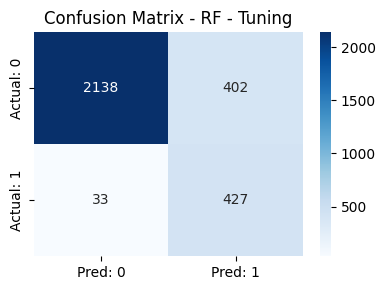

In [34]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf_base, param_rf, n_iter=15, cv=3,
                               scoring='f1', random_state=42, n_jobs=-1)
rf_search.fit(X_train_tune, y_train_tune)

print('Best params RF:', rf_search.best_params_)
print('Best F1 (CV)  :', rf_search.best_score_.round(4))

best_rf = rf_search.best_estimator_
y_pred_rf_t = best_rf.predict(X_test_tune)

result = evaluasi_model('RF - Tuning', y_test_p, y_pred_rf_t)
result['skenario'] = 'Tuning'
all_results.append(result)

### 4.5 Hyperparameter Tuning - Voting Classifier

> **Catatan untuk VotingClassifier:**  
> Tuning VotingClassifier dilakukan dengan menyetel parameter internal masing-masing estimator. Format parameter gridnya pakai prefix nama estimator + `__` + nama parameter, cara standar sklearn untuk akses parameter dalam ensemble.

In [ ]:
param_voting = {
    'lr__C': [0.1, 1, 10],
    'knn__n_neighbors': [3, 5, 7, 11]
}

estimators_t = [
    ('lr', LogisticRegression(random_state=42, max_iter=2000)),
    ('svm', SVC(random_state=42, probability=True, C=1)),
    ('knn', KNeighborsClassifier())
]

voting_base = VotingClassifier(estimators=estimators_t, voting='hard')

voting_search = RandomizedSearchCV(voting_base, param_voting, n_iter=10, cv=3,
                                   scoring='f1', random_state=42, n_jobs=-1)
voting_search.fit(X_train_tune, y_train_tune)

print('Best params Voting:', voting_search.best_params_)
print('Best F1 (CV)       :', voting_search.best_score_.round(4))

best_voting = voting_search.best_estimator_
y_pred_vot_t = best_voting.predict(X_test_tune)

result = evaluasi_model('Voting - Tuning', y_test_p, y_pred_vot_t)
result['skenario'] = 'Tuning'
all_results.append(result)

---
# BAGIAN 5: PERBANDINGAN SEMUA MODEL & IDENTIFIKASI MODEL TERBAIK

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df[['skenario', 'model', 'accuracy', 'precision', 'recall', 'f1']]
results_df = results_df.sort_values('f1', ascending=False).reset_index(drop=True)

print('=== PERBANDINGAN SEMUA MODEL ===')
print(results_df.to_string(index=False))

best_model_row = results_df.iloc[0]
print(f'\n>>> Model Terbaik: {best_model_row["model"]} dengan F1-Score = {best_model_row["f1"]:.4f} <<<')

In [ ]:
plt.figure(figsize=(10, 5))
colors = ['#5B9BD5' if 'Direct' in s else '#ED7D31' if 'Prep' in s else '#70AD47'
          for s in results_df['skenario']]
plt.bar(results_df['model'], results_df['f1'], color=colors, edgecolor='black')
plt.title('Perbandingan F1-Score Semua Model')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(results_df['f1']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Keterangan warna: Biru=Direct | Orange=Preprocessing | Hijau=Tuning')

---
# BAGIAN 6: DEPLOYMENT - SIMPAN MODEL TERBAIK

### 6.1 Simpan Model, Scaler, dan Metadata

> **Kenapa simpan scaler juga?**  
> Model dilatih dengan data yang sudah di-scale. Saat deployment, input baru dari user juga harus di-scale dengan scaler yang SAMA (parameter yang sama). Kalau scaler tidak disimpan, hasil prediksi akan salah karena input tidak ter-transform dengan benar.

> **Kenapa simpan daftar kolom hasil OHE (ohe_columns)?**  
> Saat input baru dari user (lewat form Streamlit) datang dalam bentuk kategori mentah (misal `gender = "Male"`), kita perlu tahu persis kolom-kolom OHE apa yang dipakai model (`gender_Male`, `gender_Other`, dst) supaya input bisa di-encode dengan format yang identik dengan saat training. Tanpa ini, kolom hasil OHE dari input baru bisa beda urutan/jumlah dengan yang dipelajari model.

In [ ]:
best_model_to_save = best_rf

joblib.dump(best_model_to_save, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(top_features, 'top_features.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
joblib.dump(list(X_prep.columns), 'ohe_columns.pkl')

print('File yang disimpan:')
print('  - best_model.pkl    : model terbaik')
print('  - scaler.pkl        : StandardScaler yang sudah di-fit')
print('  - top_features.pkl  : daftar nama fitur yang digunakan setelah feature selection')
print('  - label_encoders.pkl: encoder untuk fitur biner (subscription_type)')
print('  - ohe_columns.pkl   : urutan kolom lengkap setelah One-Hot Encoding')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 6.2 Test Load Model (Verifikasi)

> **Kenapa perlu test load?**  
> Sebelum deploy ke Streamlit, harus dipastikan model bisa di-load dan digunakan kembali. Ini simulasi apa yang akan dilakukan app.py nantinya.

In [ ]:
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_features = joblib.load('top_features.pkl')

sample_idx = [feature_names.index(f) for f in loaded_features]
sample = X_test_p_scaled[0:1, sample_idx]
pred = loaded_model.predict(sample)
pred_proba = loaded_model.predict_proba(sample) if hasattr(loaded_model, 'predict_proba') else None

print('Test prediksi dari model yang di-load:')
print(f'  Prediksi: {pred[0]} ({"Churn" if pred[0]==1 else "Tidak Churn"})')
if pred_proba is not None:
    print(f'  Probabilitas Churn: {pred_proba[0][1]:.4f}')
print('\nModel siap untuk deployment!')

---
# BAGIAN 7: STREAMLIT APP CODE

> Code di bawah disimpan sebagai `app.py` untuk deployment ke Streamlit Cloud

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
top_features = joblib.load("top_features.pkl")
ohe_columns = joblib.load("ohe_columns.pkl")

st.title("Customer Churn Prediction")
st.write("Aplikasi ini memprediksi apakah seorang pelanggan akan churn atau tidak.")

st.sidebar.header("Input Data Pelanggan")

age = st.sidebar.slider("Usia", 18, 80, 35)
total_visits = st.sidebar.number_input("Total Kunjungan", 0, 500, 50)
avg_session_time = st.sidebar.number_input("Avg Session Time (menit)", 0.0, 60.0, 10.0)
total_spent = st.sidebar.number_input("Total Pengeluaran", 0.0, 10000.0, 500.0)
satisfaction_score = st.sidebar.slider("Satisfaction Score (1-5)", 1, 5, 3)
nps_score = st.sidebar.slider("NPS Score (0-10)", 0, 10, 5)
support_tickets = st.sidebar.number_input("Jumlah Support Ticket", 0, 20, 1)
recency_days = st.sidebar.number_input("Recency (hari sejak beli terakhir)", 0, 365, 30)
tenure_days = st.sidebar.number_input("Tenure (hari jadi pelanggan)", 0, 3000, 365)
lifetime_value = st.sidebar.number_input("Lifetime Value", 0.0, 20000.0, 1000.0)

gender = st.sidebar.selectbox("Gender", ["Male", "Female", "Other"])
country = st.sidebar.selectbox("Country", ["India", "Germany", "USA", "UK", "Australia"])
acquisition_channel = st.sidebar.selectbox("Acquisition Channel",
    ["Email", "Organic", "Facebook Ads", "Referral", "Google Ads"])
device_type = st.sidebar.selectbox("Device Type", ["Tablet", "Desktop", "Mobile"])
payment_method = st.sidebar.selectbox("Payment Method", ["UPI", "BKash", "PayPal", "SEPA", "Card"])

raw_input = {
    "age": age, "total_visits": total_visits, "avg_session_time": avg_session_time,
    "total_spent": total_spent, "satisfaction_score": satisfaction_score,
    "nps_score": nps_score, "support_tickets": support_tickets,
    "recency_days": recency_days, "tenure_days": tenure_days,
    "lifetime_value": lifetime_value,
    "gender": gender, "country": country,
    "acquisition_channel": acquisition_channel,
    "device_type": device_type, "payment_method": payment_method
}

if st.button("Prediksi Churn"):
    input_df = pd.DataFrame([raw_input])

    # One-Hot Encode input baru dengan cara yang SAMA seperti saat training
    cat_cols_input = ["gender", "country", "acquisition_channel", "device_type", "payment_method"]
    input_df = pd.get_dummies(input_df, columns=cat_cols_input)

    # Samakan kolom dengan ohe_columns hasil training (isi 0 untuk kolom yang tidak ada)
    for col in ohe_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[[c for c in ohe_columns if c != "churn"]]

    # Ambil hanya top_features yang dipakai model
    input_df = input_df[top_features]

    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    proba = model.predict_proba(input_scaled)[0]

    if prediction == 1:
        st.error(f"Pelanggan diprediksi **CHURN** (Probabilitas: {proba[1]:.2%})")
    else:
        st.success(f"Pelanggan diprediksi **TIDAK CHURN** (Probabilitas: {proba[0]:.2%})")

    st.write("**Detail Probabilitas:**")
    st.write(f"- Tidak Churn (0): {proba[0]:.4f}")
    st.write(f"- Churn (1)      : {proba[1]:.4f}")
'''

with open("app.py", "w") as f:
    f.write(streamlit_code)

requirements = """streamlit
pandas
numpy
scikit-learn
joblib
imbalanced-learn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("app.py dan requirements.txt berhasil dibuat!")
print("\nLangkah deployment ke Streamlit Cloud:")
print("1. Upload semua file ke GitHub (app.py, requirements.txt, *.pkl)")
print("2. Login ke share.streamlit.io")
print("3. Klik New App -> pilih repo dan branch")
print("4. Set main file path ke app.py")
print("5. Deploy!")

---
## Kesimpulan

Pada proyek UAS ini telah dibangun **9 model** dari kombinasi 3 kategori model x 3 skenario eksperimen:

| Skenario | Logistic Regression | Random Forest | Voting Classifier |
|----------|--------------------|--------------|-----------------|
| Direct | OK | OK | OK |
| Preprocessing | OK | OK | OK |
| Tuning | OK | OK | OK |

Encoding fitur kategorikal nominal (`gender`, `country`, `acquisition_channel`, `device_type`, `payment_method`) menggunakan **One-Hot Encoding** karena kategori-kategori tersebut tidak punya urutan logis — pakai Label Encoding di sini berisiko membuat model salah menganggap ada hubungan ordinal antar kategori. Fitur biner (`subscription_type`) tetap memakai Label Encoding karena hasilnya identik dengan OHE untuk kasus 2 kategori.

Model terbaik dipilih berdasarkan **F1-Score** karena dataset imbalanced (84.7% tidak churn vs 15.3% churn). F1-Score lebih representatif dari accuracy untuk kondisi class imbalance karena memperhitungkan precision dan recall sekaligus.

Model terbaik kemudian di-deploy ke Streamlit Cloud untuk bisa diakses secara publik.